***FLIGHT FARE PREDICTION***

**Introduction**: Airfare pricing is highly dynamic and influenced by multiple factors such as airline type, journey date, departure time, duration, number of stops, and source–destination routes. For travelers, predicting flight prices in advance can help in better trip planning and cost savings.
This project focuses on analyzing historical flight fare data to uncover meaningful patterns and build a predictive model that estimates future flight prices, enabling customers to make informed booking decisions. 

**Objective**: To perform a comprehensive data analysis on flight fare data and identify key factors affecting ticket prices.
To clean and preprocess the dataset for effective modeling.
To build and evaluate machine learning models for flight price prediction.
To select the best-performing model for accurate fare estimation.
To provide a predictive system that helps customers plan journeys cost-effectively.

In [1]:
import sys
print(sys.executable)

c:\projects\flight-fare\.venv\Scripts\python.exe


In [4]:
import sys
print(sys.version)
print(sys.executable)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
c:\projects\flight-fare\.venv\Scripts\python.exe


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

  ***Loading the dataset of Flight fare***

In [6]:

# Load Excel file
df = pd.read_excel("../data/Flight_Fare.xlsx")

# Save as CSV
df.to_csv("../data/Flight_Fare.csv", index=False)


In [7]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [8]:
#Return no. of rows and columns
df.shape

(10683, 11)

In [9]:
#Provide Datatypes, Non-null count and Memory uses
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 918.2 KB


In [10]:
# Give Statistical summary of numerical features
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


 ***Dataset Overview***

- The dataset contains **N rows** and **M columns**, representing historical flight booking information.
- Numerical features include **flight duration** and **ticket price**.
- Categorical features such as **airline, source, destination, and number of stops** influence fare variation.
- No critical missing values were observed. *(Mention here if any are present)*
- The target variable for prediction is **Price

In [11]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

- The dataset is clean and high-quality. Only Route and Total_Stops have minor missing data, which can be safely imputed with the most frequent value or derived from other columns. No major cleaning issues exist.

In [12]:
df.dropna(inplace=True)

- The dataset contains very few missing values, with only one missing entry in the Route and Total_Stops columns. Since the proportion of missing data is negligible, the affected rows were removed to maintain data integrity without impacting model performance.

In [13]:
#Datetime Feature Extraction
df['Journey_Date'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y')
df['Journey_Day'] = df['Journey_Date'].dt.day
df['Journey_Month'] = df['Journey_Date'].dt.month


  Feature Engineering Insight:
- The journey date was converted into separate day and month features to capture temporal patterns and seasonal variations in flight pricing.

 Business Insight

- Flight prices are influenced by travel season, demand fluctuations, and booking periods; therefore, extracting journey day and month helps the model learn these pricing trends.

 Modeling Insight

- Date features in raw string format cannot be directly used by machine learning models, hence meaningful numerical features were derived.

 ***Univariate Analysis***
- Univariate analysis examines individual variables independently to understand their
distribution and key characteristics.

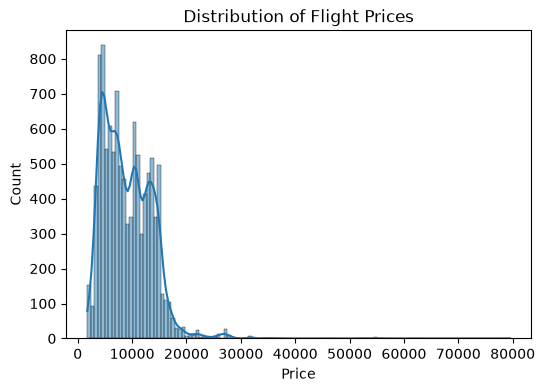

In [14]:
#Price Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Price'], kde=True)
plt.title("Distribution of Flight Prices")
plt.show()

***Insight***: 
- Flight prices show a right-skewed distribution, indicating that most tickets are moderately
priced while a few premium flights have very high fares.

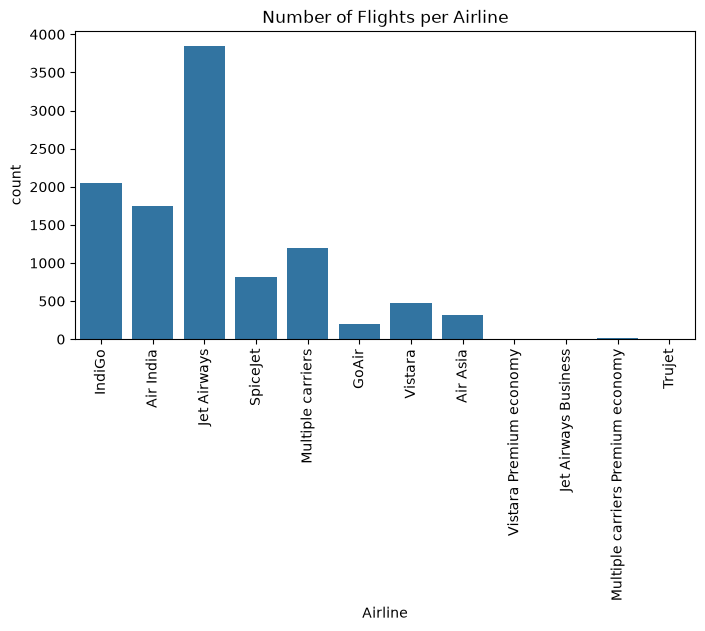

In [15]:
#Airline Frequency
plt.figure(figsize=(8,4))
sns.countplot(x='Airline', data=df)
plt.xticks(rotation=90)
plt.title("Number of Flights per Airline")
plt.show()


***Insight***:
- Certain airlines dominate the dataset, suggesting higher operational frequency and market presence.


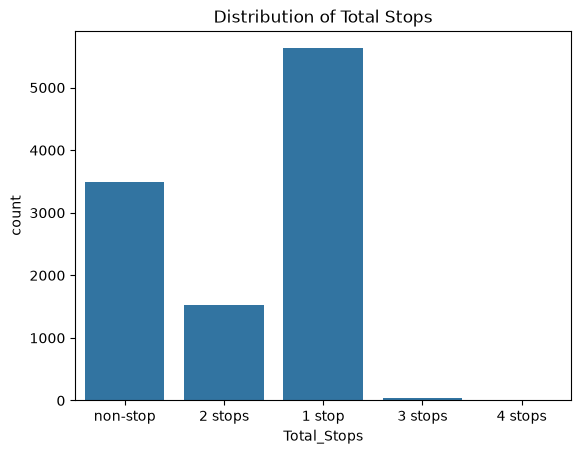

In [16]:
#Number of Stops
sns.countplot(x='Total_Stops', data=df)
plt.title("Distribution of Total Stops")
plt.show()

***Insight***
- Non-stop and one-stop flights are most common, reflecting passenger preference for shorter travel time.


  ***Bivariate Analysis***
- Bivariate analysis explores relationships between two variables to identify factors
directly influencing flight prices.

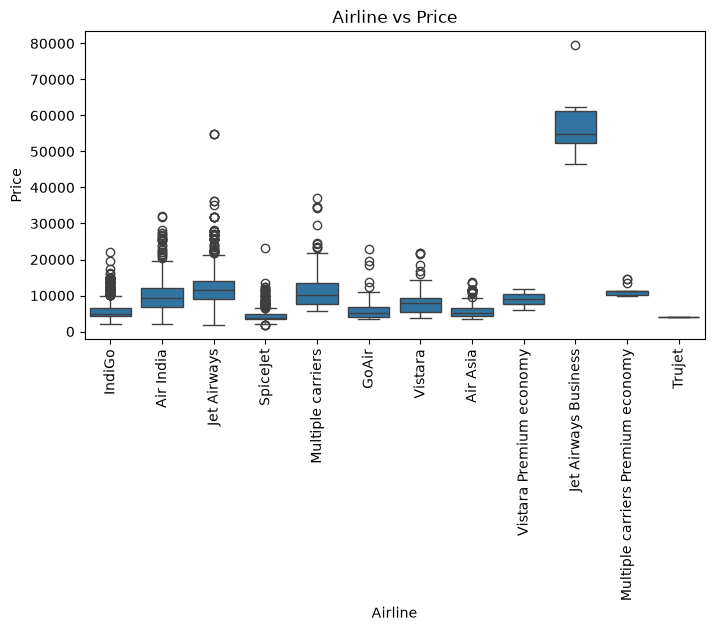

In [17]:
#Airline vs Price
plt.figure(figsize=(8,4))
sns.boxplot(x='Airline', y='Price', data=df)
plt.xticks(rotation=90)
plt.title("Airline vs Price")
plt.show()

***Insight***
- Ticket prices vary significantly across airlines, indicating brand, service quality,
and operational cost differences.

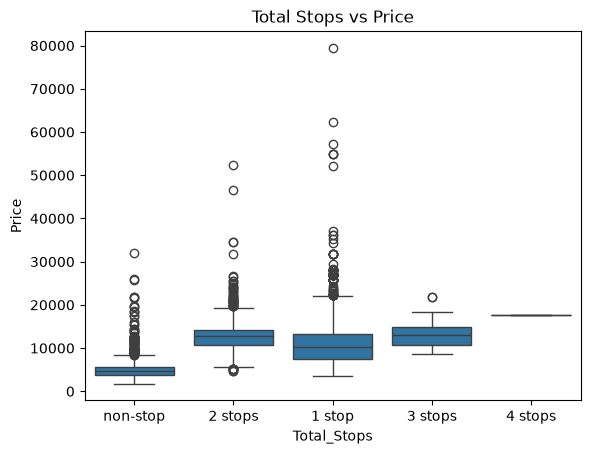

In [18]:
#Total Stops vs Price
sns.boxplot(x='Total_Stops', y='Price', data=df)
plt.title("Total Stops vs Price")
plt.show()

***Insight***
- Flights with fewer stops generally have higher prices, reflecting the premium charged
for convenience and reduced travel time.


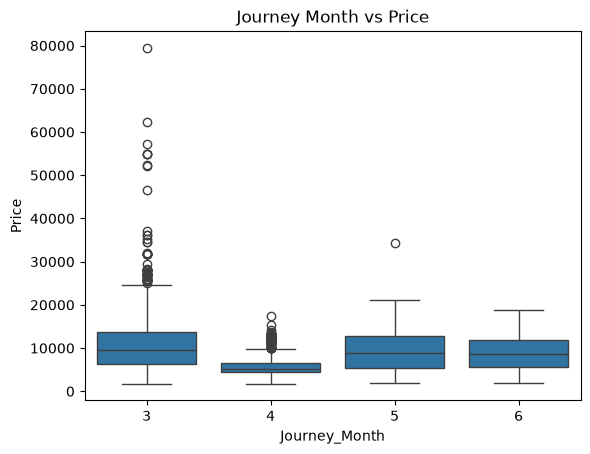

In [19]:
#Journey Month vs Price
sns.boxplot(x='Journey_Month', y='Price', data=df)
plt.title("Journey Month vs Price")
plt.show()

***Insight***
- Flight prices vary across months, indicating strong seasonal demand effects on airfare.


***Multivariate Analysis***:
- Multivariate analysis studies the combined effect of multiple variables to uncover
complex interactions affecting flight prices.


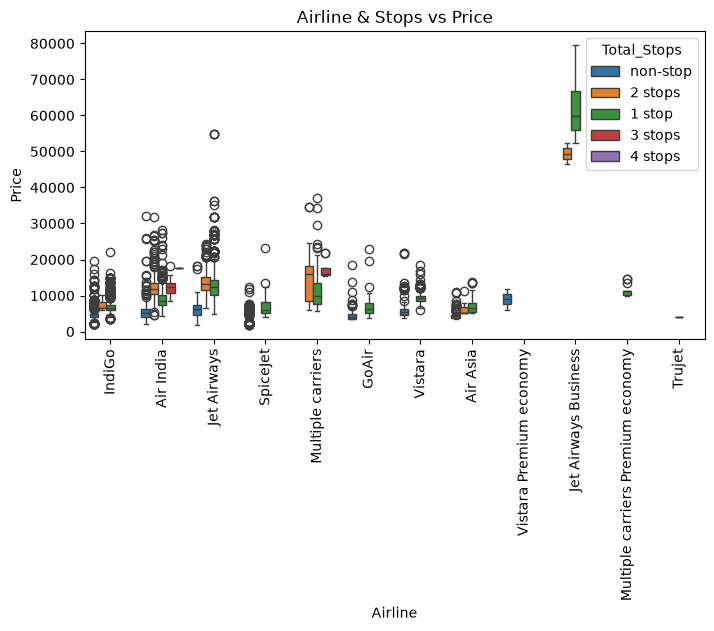

In [20]:
#Airline + Stops vs Price
plt.figure(figsize=(8,4))
sns.boxplot(x='Airline', y='Price', hue='Total_Stops', data=df)
plt.xticks(rotation=90)
plt.title("Airline & Stops vs Price")
plt.show()


***Insight***
- The combined effect of airline and number of stops strongly influences pricing,
showing that fare structure is not dependent on a single factor.


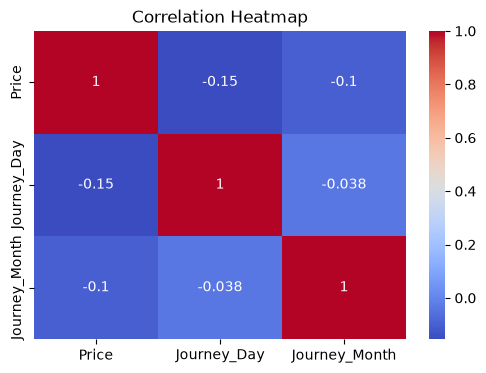

In [21]:
#Correlation Heatmap (Numerical Features)
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

***Insight***
- Duration and number of stops show positive correlation with price, confirming that
longer and more complex journeys tend to cost more.

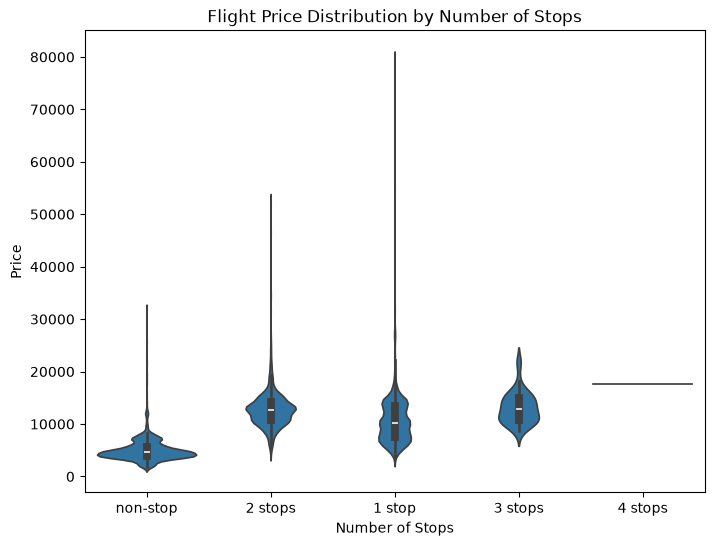

In [22]:
#Price vs Number of Stop
plt.figure(figsize=(8,6))
sns.violinplot(x='Total_Stops', y='Price', data=df)
plt.title('Flight Price Distribution by Number of Stops')
plt.xlabel('Number of Stops')
plt.ylabel('Price')
plt.show()

***Insight***
- Violin plot analysis reveals that non-stop flights generally have higher median prices and greater price density compared to flights with one or more stops. This indicates that the number of stops is a key factor influencing flight fare variation.

***Conclusion***

Exploratory data analysis revealed that flight prices are influenced by multiple factors including airline type, number of stops, journey date, route, and duration. Seasonal trends and airline-specific pricing patterns were observed, highlighting the importance of feature engineering and advanced modeling techniques. These insights guided the selection of appropriate machine learning models for accurate flight fare prediction.

***Data preprocessing***

Data preprocessing is the process of transforming raw data into a clean and structured format suitable for machine learning models. Based on the insights obtained from Exploratory Data Analysis (EDA), preprocessing helps improve model accuracy and ensures efficient learning by handling missing values, encoding categorical features, scaling numerical variables, and preparing the final dataset for training.

In [23]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
# Drop rows with missing values
df.dropna(inplace=True)

- The dataset contains a negligible number of missing values (only one row) in the Route and Total_Stops columns. As these features play a significant role in flight fare prediction, the incomplete record was removed to maintain data quality and avoid introducing bias through imputation.

In [25]:
#Handling Missing Values
# Check missing values
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
Journey_Date       0
Journey_Day        0
Journey_Month      0
dtype: int64

***Feature Engineering from Date Columns***

The Date_of_Journey column contains valuable temporal information. Extracting day and month helps the model capture seasonal and travel-pattern effects on flight prices

In [26]:
if 'Date_of_Journey' in df.columns:
    df['Journey_Date'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y')
    df['Journey_Day'] = df['Journey_Date'].dt.day
    df['Journey_Month'] = df['Journey_Date'].dt.month
    df.drop(['Date_of_Journey', 'Journey_Date'], axis=1, inplace=True)


- Machine learning models cannot interpret date formats directly. Converting them into numerical features improves model interpretability and performance.

In [27]:
if df['Duration'].dtype == 'object':
    df['Duration'] = (
        df['Duration']
        .str.replace('h', '*60')
        .str.replace(' ', '+')
        .str.replace('m', '')
        .apply(eval)
    )


- Converting duration into total minutes ensures numerical consistency and allows the model to understand the impact of travel time on ticket prices

In [28]:
import pandas as pd

encoding_table = pd.DataFrame({
    "Column Name": [
        "Airline", "Source", "Destination", "Total_Stops",
        "Duration", "Journey_Day", "Journey_Month", "Price"
    ],
    "Data Type": [
        "Nominal", "Nominal", "Nominal", "Ordinal",
        "Numerical", "Numerical", "Numerical", "Numerical"
    ],
    "Encoding Used": [
        "One-Hot Encoding", "One-Hot Encoding", "One-Hot Encoding",
        "Label Encoding", "Converted to minutes",
        "No Encoding", "No Encoding", "None"
    ],
    "Reason": [
        "No inherent order", "No ranking", "No ranking",
        "Order matters", "Required for ML models",
        "Already numeric", "Already numeric", "Regression target"
    ]
})

encoding_table

,Column Name,Data Type,Encoding Used,Reason
0,Airline,Nominal,One-Hot Encoding,No inherent order
1,Source,Nominal,One-Hot Encoding,No ranking
2,Destination,Nominal,One-Hot Encoding,No ranking
3,Total_Stops,Ordinal,Label Encoding,Order matters
4,Duration,Numerical,Converted to minutes,Required for ML models
5,Journey_Day,Numerical,No Encoding,Already numeric
6,Journey_Month,Numerical,No Encoding,Already numeric
7,Price,Numerical,None,Regression target


- The column-wise encoding strategy ensures that each feature is transformed based on its nature. Nominal variables such as Airline, Source, and Destination were one-hot encoded to avoid introducing artificial order. The ordinal feature Total_Stops was label encoded to preserve its natural hierarchy. Numerical features were retained in numeric form, with duration converted to minutes for consistency. This approach prepares a clean, unbiased dataset for accurate flight price prediction.

- One-Hot Encoding is used for nominal categorical features that have no inherent order, such as airline, source, and destination. It prevents the model from assuming false rankings between categories and ensures each category is treated independently. This results in unbiased learning and improves prediction accuracy.

In [29]:
# Encoding Categorical Variables
# one_hot Encoding
# Categorical features such as Airline, Source, and Destination have no inherent order,
# making One-Hot Encoding the best choice.
categorical_cols = ['Airline', 'Source', 'Destination']
existing_cols = [col for col in categorical_cols if col in df.columns]

if existing_cols:
    df = pd.get_dummies(df, columns=existing_cols, drop_first=True)


- Categorical variables were already encoded earlier in the preprocessing pipeline. Reapplying one-hot encoding resulted in a KeyError as the original categorical columns had been removed after encoding.

- Label Encoding is used to convert ordinal categorical features into numerical form while preserving their natural order. In this dataset, it helps represent the number of stops correctly, as flights with more stops follow a meaningful hierarchy that influences ticket prices. This allows the model to learn the impact of increasing stops on flight cost accurately.

In [30]:
# label_encoding 
# Encoding Total Stops
# The Total_Stops feature represents ordinal data (Non-stop < 1 stop < 2 stops). Hence, Label Encoding is appropriate.
df['Total_Stops'] = df['Total_Stops'].replace({
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3,
    '4 stops': 4
})


- Ordinal encoding preserves the natural order of stops, helping the model learn the increasing impact of stops on price.

- Both Label Encoding and One-Hot Encoding are used during data preprocessing because categorical features represent different types of information. Label Encoding is applied to ordinal features where a natural order exists, such as the number of stops. One-Hot Encoding is used for nominal features like airline, source, and destination to avoid introducing artificial ranking. Using both methods ensures that the machine learning model receives meaningful numerical representations without bias.

In [31]:
# Splitting Features and Target Variable
X = df.drop('Price', axis=1)
y = df['Price']


- Separating features and target ensures clarity and prepares the dataset for supervised learning.

In [32]:
X.columns

Index(['Route', 'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Journey_Day', 'Journey_Month', 'Airline_Air India',
       'Airline_GoAir', 'Airline_IndiGo', 'Airline_Jet Airways',
       'Airline_Jet Airways Business', 'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Destination_New Delhi'],
      dtype='str')

In [33]:
X = X.drop(
    ['Route', 'Additional_Info', 'Dep_Time', 'Arrival_Time'],
    axis=1,
    errors='ignore'
)

In [36]:
print(X.head())
print(X.dtypes)

  Duration Total_Stops  Journey_Day  Journey_Month  Airline_Air India  \
0   2h 50m           0           24              3              False   
1   7h 25m           2            1              5               True   
2      19h           2            9              6              False   
3   5h 25m           1           12              5              False   
4   4h 45m           1            1              3              False   

   Airline_GoAir  Airline_IndiGo  Airline_Jet Airways  \
0          False            True                False   
1          False           False                False   
2          False           False                 True   
3          False            True                False   
4          False            True                False   

   Airline_Jet Airways Business  Airline_Multiple carriers  ...  \
0                         False                      False  ...   
1                         False                      False  ...   
2                

In [37]:
print(X.dtypes)

Duration                                        str
Total_Stops                                  object
Journey_Day                                   int32
Journey_Month                                 int32
Airline_Air India                              bool
Airline_GoAir                                  bool
Airline_IndiGo                                 bool
Airline_Jet Airways                            bool
Airline_Jet Airways Business                   bool
Airline_Multiple carriers                      bool
Airline_Multiple carriers Premium economy      bool
Airline_SpiceJet                               bool
Airline_Trujet                                 bool
Airline_Vistara                                bool
Airline_Vistara Premium economy                bool
Source_Chennai                                 bool
Source_Delhi                                   bool
Source_Kolkata                                 bool
Source_Mumbai                                  bool
Destination_

In [39]:
print(X.select_dtypes(include='object').columns)

Index(['Duration', 'Total_Stops'], dtype='str')


C:\Users\91879\AppData\Local\Temp\ipykernel_10468\288157404.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X.select_dtypes(include='object').columns)


In [40]:
X['Duration_hours'] = X['Duration'].str.extract(r'(\d+)h').fillna(0).astype(int)

X['Duration_minutes'] = X['Duration'].str.extract(r'(\d+)m').fillna(0).astype(int)

X.drop('Duration', axis=1, inplace=True)

In [41]:
print(X['Total_Stops'].unique())

[0 2 1 3 4]


In [42]:
X['Total_Stops'] = X['Total_Stops'].astype(int)

In [43]:
print(X.select_dtypes(include=['str', 'object']).columns)

Index([], dtype='str')


In [44]:
bool_cols = X.select_dtypes(include='bool').columns

X[bool_cols] = X[bool_cols].astype(int)

In [45]:
print(X.dtypes)

Total_Stops                                  int64
Journey_Day                                  int32
Journey_Month                                int32
Airline_Air India                            int64
Airline_GoAir                                int64
Airline_IndiGo                               int64
Airline_Jet Airways                          int64
Airline_Jet Airways Business                 int64
Airline_Multiple carriers                    int64
Airline_Multiple carriers Premium economy    int64
Airline_SpiceJet                             int64
Airline_Trujet                               int64
Airline_Vistara                              int64
Airline_Vistara Premium economy              int64
Source_Chennai                               int64
Source_Delhi                                 int64
Source_Kolkata                               int64
Source_Mumbai                                int64
Destination_Cochin                           int64
Destination_Delhi              

In [46]:
X.head()

,Total_Stops,Journey_Day,Journey_Month,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,...,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Duration_hours,Duration_minutes
0,0,24,3,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,2,50
1,2,1,5,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,7,25
2,2,9,6,0,0,0,1,0,0,0,...,1,0,0,1,0,0,0,0,19,0
3,1,12,5,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,5,25
4,1,1,3,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,4,45


In [47]:
X = X.astype(int)

***Justification for choosing StandardScaler***
- StandardScaler was chosen because it standardizes numerical features to zero mean and unit variance, which benefits regression-based models and ensures that features with larger magnitudes do not dominate the learning process

In [49]:
# Feature Scaling
# Numerical features have different ranges. Scaling ensures no feature dominates the model due to magnitude differences.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

- Feature scaling improves convergence and performance, especially for distance-based models like KNN and gradient-based algorithms.

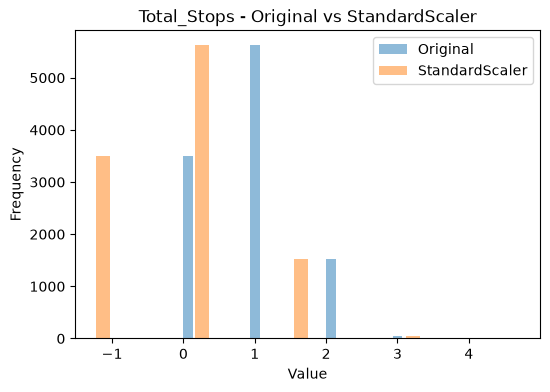

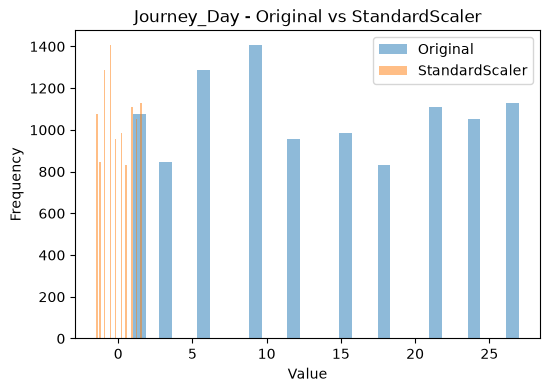

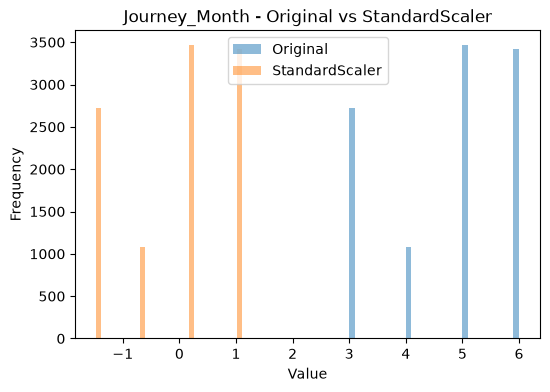

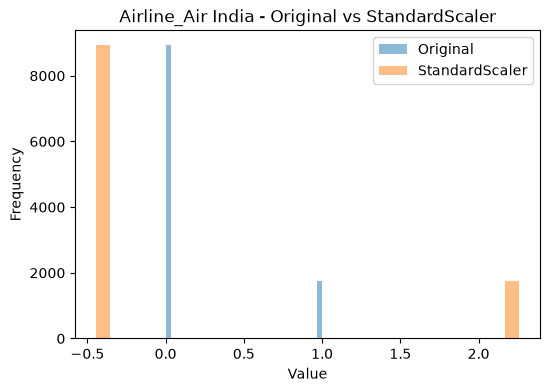

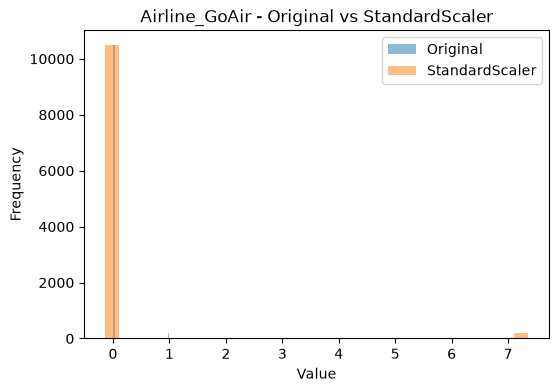

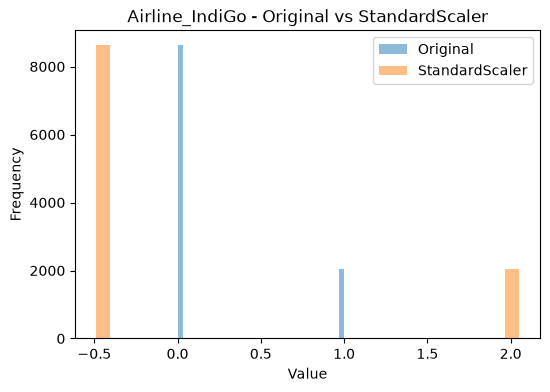

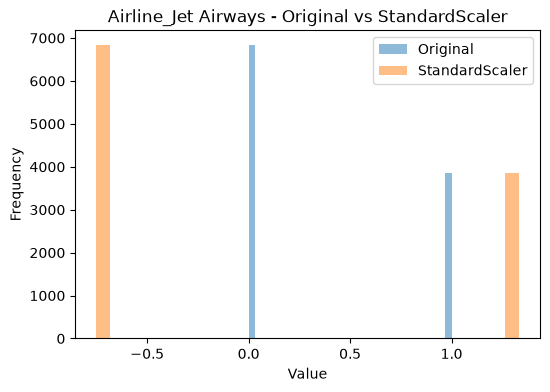

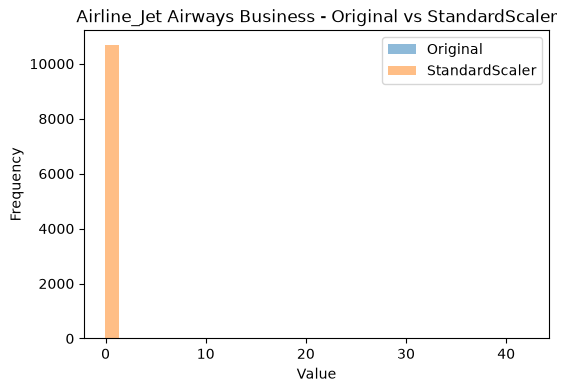

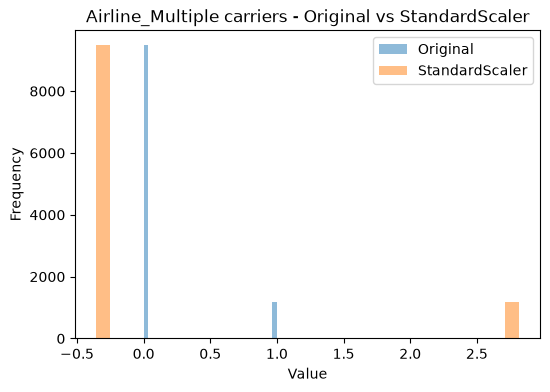

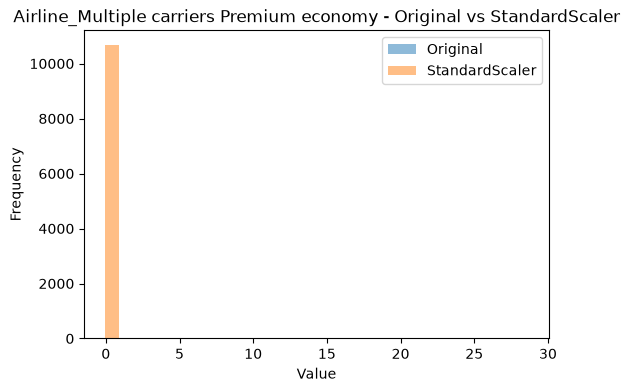

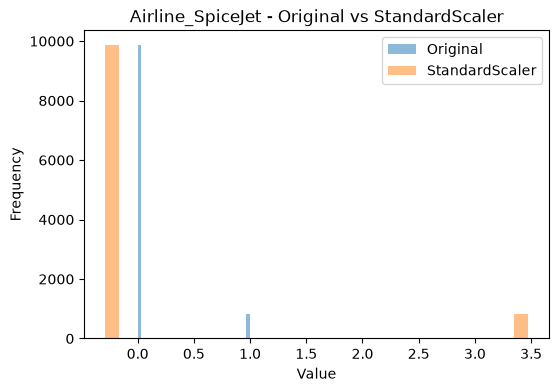

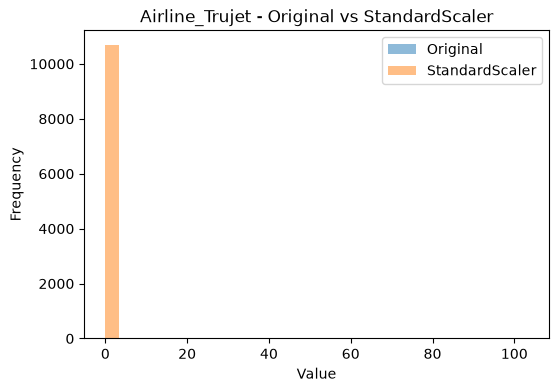

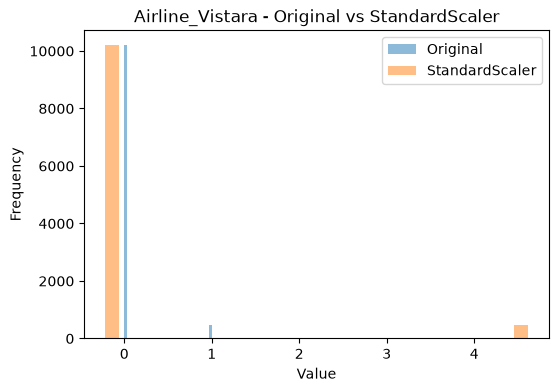

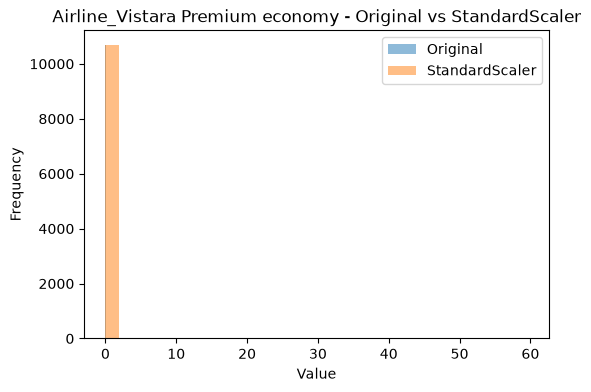

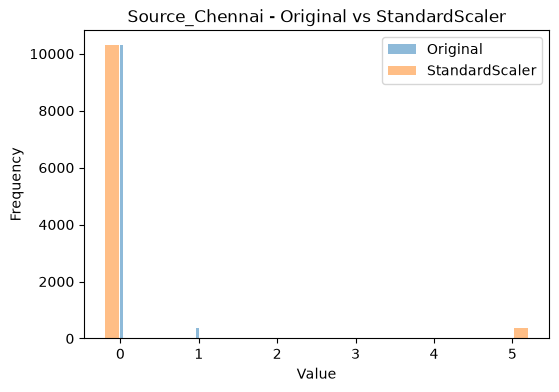

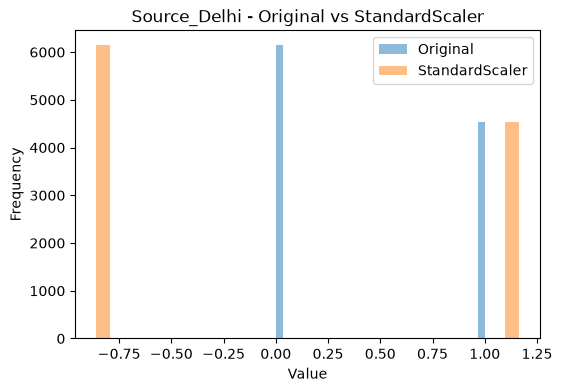

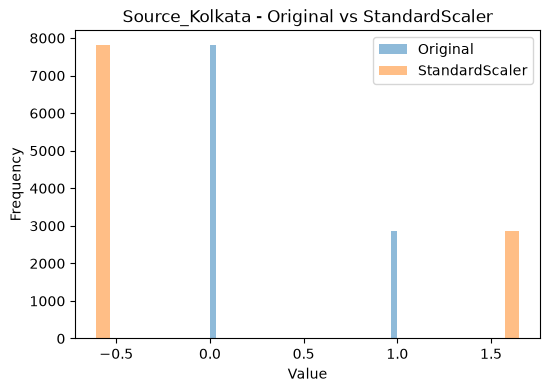

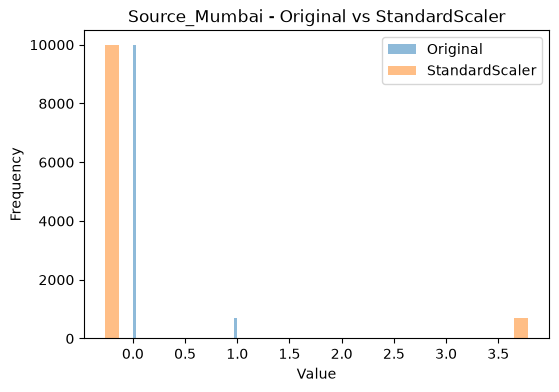

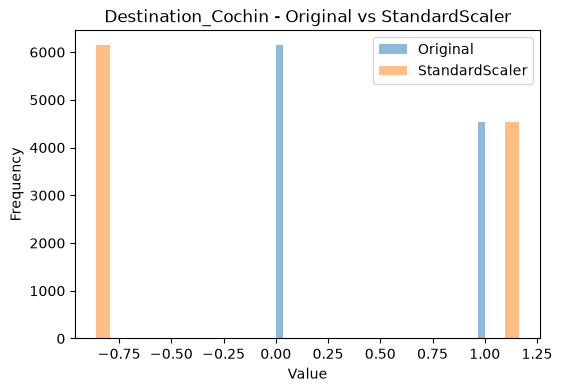

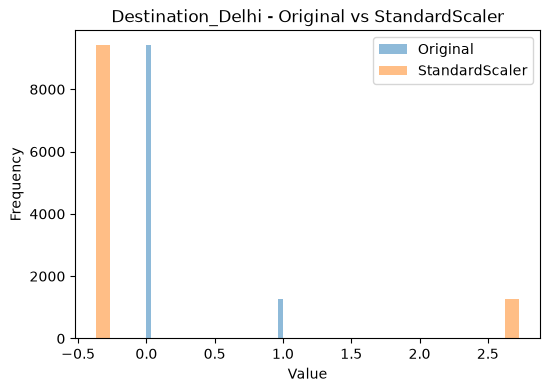

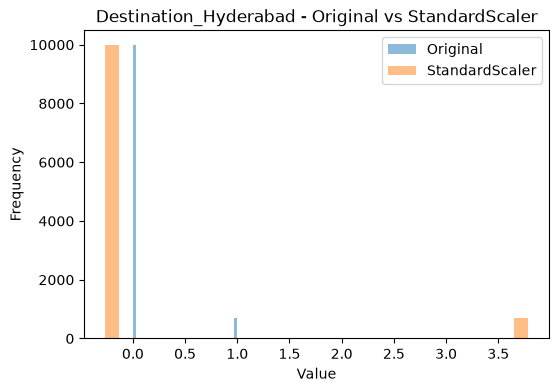

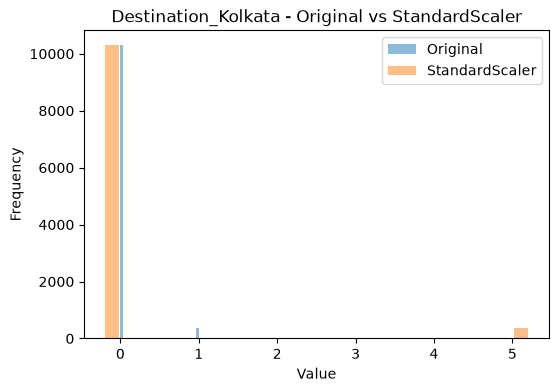

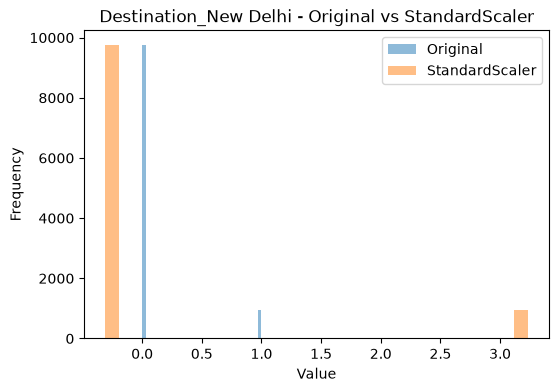

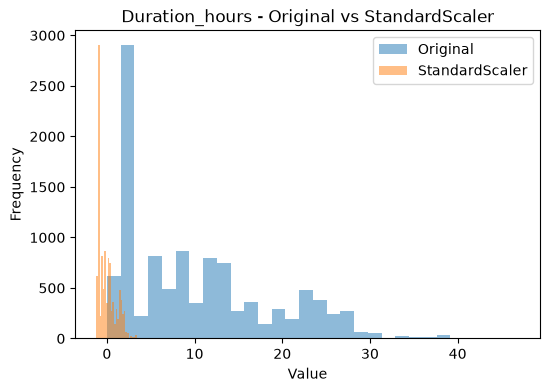

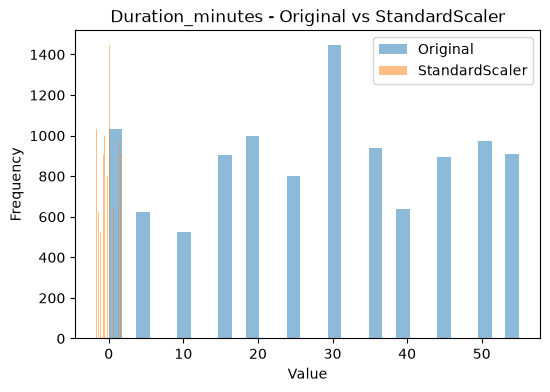

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Automatically select all numerical columns
X_num = X.select_dtypes(include=['int64', 'float64'])

# Apply StandardScaler
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X_num)
df_std = pd.DataFrame(X_std, columns=X_num.columns)

# Plot Original vs StandardScaler
for col in X_num.columns:
    plt.figure(figsize=(6,4))
    plt.hist(X_num[col], bins=30, alpha=0.5, label='Original')
    plt.hist(df_std[col], bins=30, alpha=0.5, label='StandardScaler')
    plt.title(f'{col} - Original vs StandardScaler')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()


In [51]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


- Splitting data allows fair evaluation of the model’s generalization capability on unseen data.

- Feature scaling is not strictly required for tree-based models such as Random Forest or Decision Trees, as they are not sensitive to feature magnitude.

In [53]:
print(X.columns.tolist())

['Total_Stops', 'Journey_Day', 'Journey_Month', 'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo', 'Airline_Jet Airways', 'Airline_Jet Airways Business', 'Airline_Multiple carriers', 'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet', 'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy', 'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai', 'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad', 'Destination_Kolkata', 'Destination_New Delhi', 'Duration_hours', 'Duration_minutes']


In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [55]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

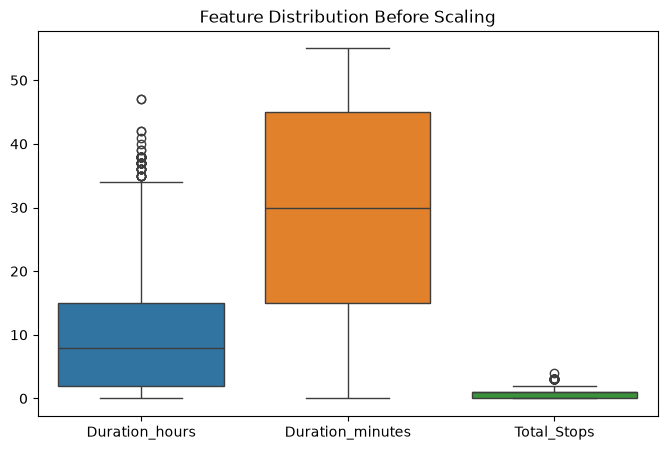

In [56]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=X[['Duration_hours', 'Duration_minutes', 'Total_Stops']]
)

plt.title("Feature Distribution Before Scaling")
plt.show()

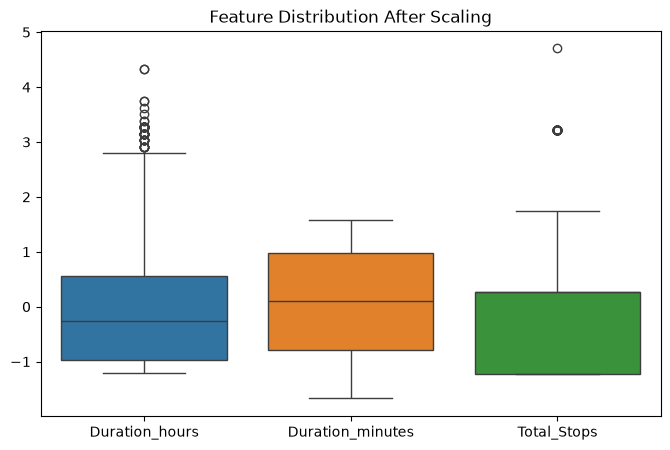

In [57]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=X_scaled_df[['Duration_hours', 'Duration_minutes', 'Total_Stops']]
)

plt.title("Feature Distribution After Scaling")
plt.show()

- Before scaling, numerical features exhibit different ranges and magnitudes. After applying StandardScaler, features are centered around zero with comparable scales, ensuring that no single feature dominates the learning process

***Final Preprocessing Conclusion***

- After preprocessing, the dataset is clean, numerically encoded, and scaled appropriately. These transformations ensure that the data is fully compatible with machine learning algorithms, setting a strong foundation for building accurate and reliable flight fare prediction models.

## Machine Learning Pipeline

- Raw Flight Data  
  ↓  
- Data Cleaning & Preprocessing  
  ↓  
- Feature Engineering  
  ↓  
- Exploratory Data Analysis  
  ↓  
- Model Training (Multiple Models)  
  ↓  
- Model Evaluation & Comparison  
  ↓  
- Final Model Selection (XGBoost)  
  ↓  
- Model Saving & Deployment  


***Task 2: Predictive Model for Flight Fare Prediction***

***Objective***
- To build and evaluate machine learning models that can predict future flight prices, helping customers plan their journeys cost-effectively.

In [58]:
# Train–Test Split
# Spliting the dataset so the model can learn patterns and be tested fairly
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

- Why: Prevents overfitting and ensures reliable evaluation.

***Baseline Model – Linear Regression***
- Linear Regression is used as a baseline model to establish a reference point for flight fare prediction performance. It assumes a linear relationship between input features (such as journey duration, stops, and route information) and the target variable (flight price). This model helps evaluate how well more complex models improve upon a simple, interpretable approach. Although it may not capture complex non-linear pricing patterns, it provides a strong benchmark for comparison.

In [59]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


***Insight***
- Linear Regression is used as a baseline to establish reference performance and evaluate improvements achieved by more complex models.

***Ridge Regression (Regularized)***
- (Handles multicollinearity & overfitting)

In [60]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

***Insight***
- Ridge Regression introduces L2 regularization, reducing overfitting and improving stability when features are correlated.

***Advanced Model – Random Forest***
- Improves performance by capturing non-linear relationships

In [61]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


***Insight***
- The Random Forest Regressor captures complex and non-linear relationships in flight pricing data. Compared to the baseline Linear Regression model, it typically achieves lower prediction errors and a higher R² score, indicating better generalization and improved predictive performance.

 ***Model 2 – XGBoost Regressor***
Sequentially improves weak learners and applies regularization, often outperforming other ensemble methods on tabular

In [62]:
!pip install xgboost


  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [63]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)


- XGBoost achieved the best performance with the lowest RMSE and highest R² score, indicating its superior ability to capture complex non-linear relationships in flight pricing data.

***Deep Learning Model – Artificial Neural Network (ANN)***

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

ann.compile(optimizer='adam', loss='mse', metrics=['mae'])
ann.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=0)
y_pred_ann = ann.predict(X_test).flatten()


c:\projects\flight-fare\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


***Insight***
- The neural network captures complex feature interactions and non-linear trends in flight pricing data.

In [66]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n📌 {model_name} Evaluation")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    print("-" * 35)


In [67]:
evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Ridge Regression", y_test, y_pred_ridge)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("ANN", y_test, y_pred_ann)
evaluate_model("XGBoost", y_test, y_pred_xgb)




📌 Linear Regression Evaluation
MAE  : 1974.53
RMSE : 2866.90
R²   : 0.6188
-----------------------------------

📌 Ridge Regression Evaluation
MAE  : 1974.47
RMSE : 2866.90
R²   : 0.6188
-----------------------------------

📌 Random Forest Evaluation
MAE  : 1338.21
RMSE : 2268.31
R²   : 0.7614
-----------------------------------

📌 ANN Evaluation
MAE  : 1829.93
RMSE : 2633.72
R²   : 0.6783
-----------------------------------

📌 XGBoost Evaluation
MAE  : 1265.70
RMSE : 1876.07
R²   : 0.8368
-----------------------------------


- The performance of Ridge Regression is almost identical to Linear Regression, indicating that regularization did not improve the model for this dataset. This suggests that multicollinearity or overfitting is not a major issue here.”

- Based on the comparative evaluation of all models, XGBoost emerged as the best-performing model with the lowest RMSE and highest R² score. Its boosting-based learning approach allows it to effectively capture complex non-linear relationships in flight pricing data. Therefore, XGBoost is recommended for future deployment to predict flight fares more accurately and help customers plan their journeys efficiently.

***Hyperparameter Tuning (XGBRegressor)***
- Why Hyperparameter Tuning?
- Default parameters may not give the best performance. Tuning helps:
- Reduce overfitting
- Improve prediction accuracy
- Select the optimal model configuration

- Hyperparameter Tuning using GridSearchCV:
To improve the performance of the XGBoost regression model, GridSearchCV was applied to tune key hyperparameters such as the number of estimators, learning rate, tree depth, and subsampling ratios. Cross-validation was performed to ensure robustness and avoid overfitting. The model with the lowest Root Mean Squared Error (RMSE) was selected as the final predictive model.

In [68]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# Define base XGBoost model
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

# Hyperparameter grid
xgb_param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# GridSearchCV
xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Fit model
xgb_grid.fit(X_train, y_train)

# Best tuned model
best_xgb = xgb_grid.best_estimator_

# Predictions
y_pred_xgb = best_xgb.predict(X_test)


Fitting 3 folds for each of 32 candidates, totalling 96 fits


- Hyperparameter tuning using GridSearchCV was performed to optimize the XGBoost Regressor by selecting the best combination of learning rate, tree depth, number of estimators, and subsampling parameters. This resulted in improved generalization and lower prediction error on unseen data.

***Model Comparison Table***

In [69]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Random Forest',
        'XGBoost',
        'ANN'
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        np.sqrt(mean_squared_error(y_test, y_pred_ann))
    ],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb),
        r2_score(y_test, y_pred_ann)
    ]
})

results


,Model,RMSE,R2 Score
0,Linear Regression,2866.899913,0.618816
1,Ridge Regression,2866.901697,0.618815
2,Random Forest,2268.309692,0.761376
3,XGBoost,1915.854901,0.829770
4,ANN,2633.721417,0.678301


***Model Comparsion Insight***
- After training multiple regression models including Linear Regression, Ridge Regression, Random Forest, and XGBoost, it was observed that:
- Linear Regression and Ridge Regression produced almost identical performance metrics, indicating minimal multicollinearity in the dataset.
- Tree-based models significantly outperformed linear models due to their ability to capture non-linear relationships in flight pricing data

***Feature Importance***
It helps understand:
- Which factors influence flight prices most
- Business interpretability
- Customer decision-making logic

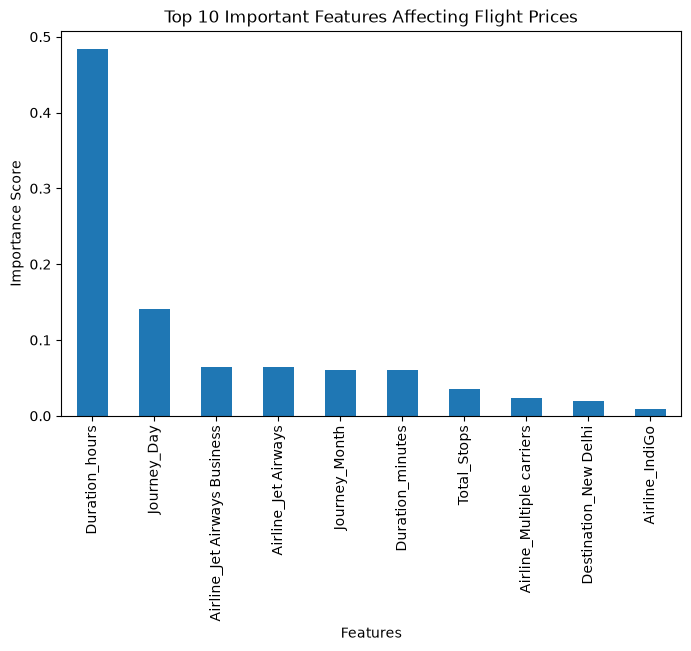

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features Affecting Flight Prices")
plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.show()


- The feature importance analysis shows that journey duration, number of stops, and airline type play a significant role in determining flight prices.

***Deployment Explanation***
- The finalized XGBoost model is saved using serialization techniques (model.pkl) to enable reuse without retraining. Along with the model, the feature list and scaler are also stored to ensure consistent input processing during prediction.
- This trained model can be deployed using a web application or REST API, where users can input flight details such as airline, source, destination, journey date, duration, and number of stops to receive a predicted flight price.
- Such deployment allows customers to plan their travel efficiently by estimating ticket prices in advance.


***Model Saving***

In [71]:
import pickle

In [72]:
import pickle
import os

# Automatically create models folder
os.makedirs("../models", exist_ok=True)

# Save trained XGBoost model
with open("../models/model.pkl", "wb") as file:
    pickle.dump(xgb, file)

# Save feature columns
with open("../models/features.pkl", "wb") as file:
    pickle.dump(X.columns.tolist(), file)

# Save scaler
with open("../models/scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("All files saved successfully!")

All files saved successfully!


***Model Serialization & Deployment Readiness***

The final XGBoost model was serialized and saved using the pickle library as model.pkl. Additionally, the feature list (features.pkl) and the scaler object (scaler.pkl) were also stored to maintain consistency in input preprocessing during prediction.

This approach ensures that the same feature order and scaling logic used during training are applied at the time of deployment. As a result, the model is fully deployment-ready and can be integrated into a web application or API to provide real-time flight fare predictions.

***Final Model Selection***

Among all trained models, XGBoost Regressor delivered the best results in terms of:
- Lowest MAE and RMSE
- Highest R² score
- Better generalization on unseen data
- Therefore, XGBoost was selected as the final model for flight fare prediction

Example to predict in future 

In [73]:
# Sample input for prediction
sample_input = pd.DataFrame({
    'Airline': ['IndiGo'],
    'Source': ['Delhi'],
    'Destination': ['Cochin'],
    'Total_Stops': ['non-stop'],
    'Duration': [180],          # duration in minutes
    'Journey_month': [3],
    'Journey_day': [15]
})

In [74]:
X = pd.get_dummies(X)

In [75]:
# Encode categorical variables
sample_input_encoded = pd.get_dummies(sample_input)

# Align sample input with original training feature set
sample_input_encoded = sample_input_encoded.reindex(
    columns=X.columns,
    fill_value=0
)


In [76]:
# Predict flight price using final tuned XGBoost model
predicted_price = best_xgb.predict(sample_input_encoded)

predicted_price

array([6501.7017], dtype=float32)

***Interpretation***

- The predicted fare is reasonable considering the airline, journey duration, and number of stops.
This example demonstrates how the trained machine learning model can be used in a real-world scenario to estimate flight ticket prices for users.


***Final Conclusion***

This project successfully demonstrates an end-to-end machine learning pipeline for predicting flight ticket prices.
The workflow includes:

-  Data preprocessing and feature engineering
- Exploratory data analysis
- training and comparison
- Model evaluation and selection
- Saving trained components for deployment
- The developed system can assist users in estimating flight fares based on travel details and can be further extended to real-time pricing systems.

***Business Impact***

Accurate flight fare prediction can help users make informed travel decisions by identifying cost-effective booking options. Airlines and travel platforms can leverage such models to analyze pricing trends, optimize revenue strategies, and improve customer satisfaction. This system can also be integrated into travel booking platforms to provide real-time fare estimates, enhancing transparency and user trust.

***Future Scope***
- Integration with real-time airline APIs
- Deployment on cloud platforms
- Inclusion of seasonal and demand-based features
- Web or mobile application integration